# **Earnings Probability Model Analysis**

## Earnings Probability Notebook for all calculated stock features

### Covers Earnings metrics including EPS analysis, GAAP adjustments, and revision trends. Source functions:
- `probabilistic_ml_model.pymc_models.EarningsBeatModel.EarningsBeatBayesian` — hierarchical Beta-Binomial beat-probability model with DB-aligned `pm.Data` containers (`n_total`, `n_beats`, `sector_idx`, `earnings_features`).
- `public.vw_features_earnings` — source view for earnings features.
- `public.calculated_features_registry` (category = `Earnings`) — drives the `earnings_feature` coord labels.


In [1]:
import numpy as np

try:
    import arviz as az
except ImportError:
    import arviz_base as az
import matplotlib.pyplot as plt

from probabilistic_ml_model.pymc_models.EarningsBeatModel import EarningsBeatBayesian
from probabilistic_ml_model.data_utils.data_utils import load_feature_categories_from_db


In [2]:
%%sql
select * from public.vw_features_earnings vfe
where eps_surprise_pct is not null
order by isin


,isin,ticker,name,description,region,country,trading_country,exchange,sector,industry,...,forward_eps_gaap_adj_spread,gaap_revision_momentum,gaap_revision_1m,gaap_revision_3m,gaap_revision_6m,gaap_revision_1y,gaap_vs_norm_revision_spread,gaap_revision_acceleration,gaap_positive_revision_flag,revision_quality_divergence
0,AEA001901015,AGTHIA,Agthia Group PJSC,Agthia Group PJSC operates in the food and bev...,Africa / Middle East,AE,AE,ADX,Consumer Staples,Food Products,...,-0.01,-0.106600,0.0628,-0.0912,-0.2532,-0.3372,-0.0484,0.3160,0,0.0143
1,AEA003001012,AIRARABIA,Air Arabia PJSC,Air Arabia PJSC together with its subsidiaries...,Africa / Middle East,AE,AE,DFM,Industrials,Passenger Airlines,...,-0.01,-0.025820,-0.0415,-0.0908,0.0198,0.0799,-0.0090,-0.0613,0,0.0206
2,AEA006101017,ADNOCDIST,Abu Dhabi National Oil Company for Distributio...,Abu Dhabi National Oil Company for Distributio...,Africa / Middle East,AE,AE,ADX,Consumer Discretionary,Specialty Retail,...,0.00,0.004540,-0.0514,-0.0102,0.0678,0.0802,0.0125,-0.1192,0,0.0095
3,AEA007301012,ADNOCDRILL,ADNOC Drilling Company P.J.S.C.,ADNOC Drilling Company P.J.S.C. engages in the...,Africa / Middle East,AE,AE,ADX,Energy,Energy Equipment and Services,...,0.00,-0.041520,-0.0148,-0.0372,-0.0635,-0.0832,0.0083,0.0487,0,0.0055
4,AED000701014,DANA,Dana Gas PJSC,Dana Gas PJSC together with its subsidiaries e...,Africa / Middle East,AE,AE,ADX,Energy,Oil Gas and Consumable Fuels,...,0.01,-0.218650,-0.3363,-0.3363,-0.0002,-0.0001,0.2272,-0.3361,0,0.0026
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3493,VN000000HPG4,HPG,Hoa Phat Group Joint Stock Company,Hoa Phat Group Joint Stock Company produces an...,Asia / Pacific,VN,VN,HOSE,Materials,Metals and Mining,...,0.00,-0.029065,-0.0056,-0.0553,-0.0339,-0.0249,0.0085,0.0283,0,0.0044
3494,VN000000MWG0,MWG,Mobile World Investment Corporation,Mobile World Investment Corporation together w...,Asia / Pacific,VN,VN,HOSE,Consumer Discretionary,Specialty Retail,...,0.00,0.185830,0.0706,0.1834,0.2806,0.3332,0.0000,-0.2100,1,0.0000
3495,VN000000SAB4,SAB,Saigon Beer - Alcohol - Beverage Corporation,Saigon Beer - Alcohol - Beverage Corporation t...,Asia / Pacific,VN,VN,HOSE,Consumer Staples,Beverages,...,0.00,0.027015,0.0374,0.0402,0.0448,-0.0473,0.0000,-0.0074,1,0.0000
3496,VN000000VNM8,VNM,Vietnam Dairy Products Joint Stock Company,Vietnam Dairy Products Joint Stock Company pro...,Asia / Pacific,VN,VN,HOSE,Consumer Staples,Food Products,...,0.00,-0.000740,0.0021,0.0102,0.0293,-0.0693,0.0069,-0.0272,1,0.0064


In [3]:
earnings_df.describe()


,reporting_interval,eps_surprise_pct,revenue_surprise_pct,eps_adjustment_ratio,gaap_adj_eps_gap_pct,ebitda_adjustment_ratio,eps_quarterly_trend,eps_yoy_growth,eps_qoq_growth,eps_yoy_quarterly,...,forward_eps_gaap_adj_spread,gaap_revision_momentum,gaap_revision_1m,gaap_revision_3m,gaap_revision_6m,gaap_revision_1y,gaap_vs_norm_revision_spread,gaap_revision_acceleration,gaap_positive_revision_flag,revision_quality_divergence
count,3493.000000,3498.000000,3423.000000,3470.000000,3425.000000,3483.000000,3324.000000,3451.000000,3352.000000,3324.000000,...,3425.000000,3498.000000,2932.000000,2901.000000,2868.000000,2818.000000,2884.000000,2859.000000,3498.000000,2871.000000
mean,10.119095,-27.049712,-5.332002,1.136922,-20.082049,0.666521,0.697807,8.892681,-1.289811,69.780666,...,0.318070,0.055199,0.040949,0.077292,0.096008,0.067956,1.171903,-0.057474,0.196398,1.338753
std,3.610887,735.254172,134.660796,7.478219,191.785770,11.984578,17.715487,745.558668,1249.702705,1771.548739,...,1.704173,0.730500,0.486405,1.320119,1.965063,1.389409,64.389954,1.961646,0.397330,64.508467
min,3.000000,-21000.000000,-100.000000,-67.000000,-5400.000000,-665.123711,-112.000000,-19666.666667,-34200.000000,-11200.000000,...,-35.230000,-0.988150,-0.987900,-1.000000,-0.989200,-1.000000,-61.514900,-80.368700,0.000000,0.000000
25%,12.000000,-44.444444,-14.548130,0.680219,-15.384615,0.766014,-0.284241,-23.529412,-43.570703,-28.424107,...,0.000000,-0.064421,-0.012825,-0.089800,-0.132650,-0.216175,-0.018100,-0.062550,0.000000,0.004900
50%,12.000000,-14.285714,-6.544495,1.000000,-1.415094,1.024748,0.114896,11.111111,0.000000,11.489570,...,0.020000,0.000000,0.000000,-0.011000,-0.016450,-0.039000,0.000800,0.017400,0.000000,0.019500
75%,12.000000,-2.358491,-1.911683,1.119828,0.000000,1.163977,0.717366,53.402778,46.957014,71.736597,...,0.260000,0.034219,0.017025,0.051200,0.084125,0.113225,0.029100,0.113300,0.000000,0.065600
max,12.000000,31800.000000,7066.666667,258.666667,4000.000000,109.402390,719.000000,11433.333333,22300.000000,71900.000000,...,62.490000,27.289605,11.468500,61.500000,81.286900,51.167700,3457.131600,10.846100,1.000000,3455.832200


## 1. Prepare inputs for `EarningsBeatBayesian`

We map columns from `public.vw_features_earnings` onto the model's `pm.Data` containers:

| Container           | Source column(s)                                                 |
|---------------------|------------------------------------------------------------------|
| `n_beats` (isin,)   | `eps_positive_years` (proxy for beats count)                     |
| `n_total` (isin,)   | `eps_total_reports` if available, else fixed 10-year window      |
| `isin`  coord       | `isin` (role=`id` in `vw_identifier_columns`)                    |
| `sector` coord      | `sector` (role=`categorical`) — enables hierarchical structure   |
| `earnings_features` | full earnings-feature matrix keyed by `calculated_features_registry` |


In [4]:
# Canonical ID column
id_col = "isin" if "isin" in earnings_df.columns else "ticker"

# Beats / totals
beats_col = "eps_positive_years"  # integer proxy for earnings beats
totals_col = "eps_total_reports" if "eps_total_reports" in earnings_df.columns else None
default_window = 10  # fallback lookback window

valid_mask = earnings_df[beats_col].notna() & earnings_df[id_col].notna()
eb_df = earnings_df.loc[valid_mask].drop_duplicates(subset=id_col).reset_index(drop=True)

if totals_col is not None:
    n_total = eb_df[totals_col].fillna(default_window).astype(int).clip(lower=1).to_numpy()
else:
    n_total = np.full(len(eb_df), default_window, dtype="int32")

n_beats = np.clip(eb_df[beats_col].astype(int).to_numpy(), 0, n_total)

isins = eb_df[id_col].astype(str).to_numpy()
sectors = eb_df["sector"].astype(str).to_numpy() if "sector" in eb_df.columns else None

print(f"Prepared inputs: {len(eb_df)} stocks")
print(f"  n_beats:  mean={n_beats.mean():.2f}  min={n_beats.min()}  max={n_beats.max()}")
print(f"  n_total:  mean={n_total.mean():.2f}  min={n_total.min()}  max={n_total.max()}")
if sectors is not None:
    print(f"  sectors:  {len(np.unique(sectors))} unique")


Prepared inputs: 3498 stocks
  n_beats:  mean=3.77  min=0  max=5
  n_total:  mean=10.00  min=10  max=10
  sectors:  9 unique


### 1.1 Build the auxiliary `earnings_features` matrix

The matrix is aligned to the `earnings_feature` dim whose labels are resolved from
`public.calculated_features_registry` (category = `Earnings Quality`).


In [5]:
earnings_categories = load_feature_categories_from_db()
_EARNINGS_KEYS = ("Earnings Quality", "EPS Trajectory")
earnings_feature_aliases: list[str] = []
_seen: set[str] = set()
for _key in _EARNINGS_KEYS:
    for _alias in earnings_categories.get(_key, []):
        if _alias not in _seen:
            _seen.add(_alias)
            earnings_feature_aliases.append(_alias)
print(f"Registry reports {len(earnings_feature_aliases)} '{_EARNINGS_KEYS}' feature aliases")

available_features = [c for c in earnings_feature_aliases if c in eb_df.columns]
print(f"  {len(available_features)} of them are present in vw_features_earnings.")

# The model's internal `_align_earnings_features` handles missing columns, so we
# can pass the full frame keyed by `isin` (de-duplicated up-front).
earnings_features_df = (
    eb_df[[id_col] + available_features]
    .rename(columns={id_col: "isin"})
    .drop_duplicates(subset="isin")
)


Registry reports 21 '('Earnings Quality', 'EPS Trajectory')' feature aliases
  20 of them are present in vw_features_earnings.


## 2. Fit the hierarchical Beta-Binomial model

The model stores observed/design data as `pm.Data` containers so they appear in
`idata.constant_data` and can be swapped via `pm.set_data({...})` for
out-of-sample prediction.


In [6]:
earnings_bayesian = EarningsBeatBayesian()

print(f"Sampling EarningsBeatBayesian over {len(eb_df)} stocks "
      f"({'hierarchical by sector' if sectors is not None else 'pooled'})...")

earnings_idata, earnings_bayesian_model = earnings_bayesian.fit(
    n_beats=n_beats,
    n_total=n_total,
    isins=isins,
    sectors=sectors,
    earnings_features_df=earnings_features_df,
    samples=1000,
    tune=1000,
    chains=4,
    target_accept=0.8,
    random_seed=42,
    parameterization="marginalized",  # collapses 500 per-stock Beta latents
    nuts_sampler="nutpie",  # Rust NUTS — ~5–10x faster than pure-Python pymc sampler
    idata_kwargs={"log_likelihood": False},
)

earnings_idata

Sampling EarningsBeatBayesian over 3498 stocks (hierarchical by sector)...


C:\Users\markm\AppData\Local\Programs\Python\Python314\Lib\site-packages\pymc\sampling\mcmc.py:361: UserWarning: `idata_kwargs` are currently ignored by the nutpie sampler
  warnings.warn(


Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,0,0.37,15
,2000,1,0.35,15
,2000,0,0.35,15
,2000,0,0.34,39


Inference data with groups:
	> posterior
	> sample_stats
	> observed_data
	> constant_data

Warmup iterations saved (warmup_*).

## 3. Inspect the `constant_data` group

`pm.Data` containers are automatically persisted into `idata.constant_data`,
carrying the DB-aligned coords (`isin`, `sector`, `earnings_feature`).


In [7]:
if hasattr(earnings_idata, "constant_data"):
    print("constant_data variables:", list(earnings_idata.constant_data.data_vars))
    print("constant_data coords:   ", list(earnings_idata.constant_data.coords))
    print(earnings_idata.constant_data)


constant_data variables: ['n_total', 'n_beats', 'earnings_features', 'sector_idx']
constant_data coords:    ['isin', 'earnings_feature']
<xarray.Dataset> Size: 800kB
Dimensions:            (isin: 3498, earnings_feature: 21)
Coordinates:
  * isin               (isin) <U12 168kB 'AEA001901015' ... 'ZAE000006284'
  * earnings_feature   (earnings_feature) <U27 2kB 'eps_surprise_pct' ... 'ep...
Data variables:
    n_total            (isin) int32 14kB 10 10 10 10 10 10 ... 10 10 10 10 10 10
    n_beats            (isin) int32 14kB 5 5 5 5 5 5 5 4 3 ... 0 3 5 5 5 4 5 4 4
    earnings_features  (isin, earnings_feature) float64 588kB -62.5 ... 0.0
    sector_idx         (isin) int32 14kB 2 5 1 3 3 8 0 7 5 ... 4 3 2 6 7 1 2 2 7
Attributes:
    created_at:                 2026-04-26T09:00:08.230618+00:00
    arviz_version:              0.23.4
    inference_library:          pymc
    inference_library_version:  5.28.4


## 4. Posterior diagnostics


In [8]:
summary = az.summary(
    earnings_idata,
    var_names=(["sector_rate", "kappa", "mu_logit", "sigma_sector"] if sectors is not None else ["mu_logit"]),
    round_to=3,
)
summary.head(20)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sector_rate[Communication Services],0.361,0.013,0.338,0.387,0.000,0.000,4645.781,2689.388,1.001
sector_rate[Consumer Discretionary],0.404,0.008,0.390,0.419,0.000,0.000,4864.818,2939.364,0.999
sector_rate[Consumer Staples],0.445,0.011,0.424,0.466,0.000,0.000,5887.510,3361.221,1.001
sector_rate[Energy],0.411,0.010,0.391,0.430,0.000,0.000,5659.072,3211.880,1.002
sector_rate[Health Care],0.247,0.007,0.234,0.259,0.000,0.000,4234.392,3518.821,1.000
sector_rate[Industrials],0.415,0.006,0.404,0.427,0.000,0.000,5315.039,3357.295,1.001
sector_rate[Information Technology],0.372,0.007,0.358,0.384,0.000,0.000,5445.083,3226.813,1.000
sector_rate[Materials],0.362,0.009,0.346,0.379,0.000,0.000,5454.764,3241.750,1.001
sector_rate[Utilities],0.450,0.015,0.423,0.478,0.000,0.000,3630.049,1307.004,1.002
kappa,36.799,4.629,28.675,45.520,0.082,0.100,3442.567,2647.115,1.000


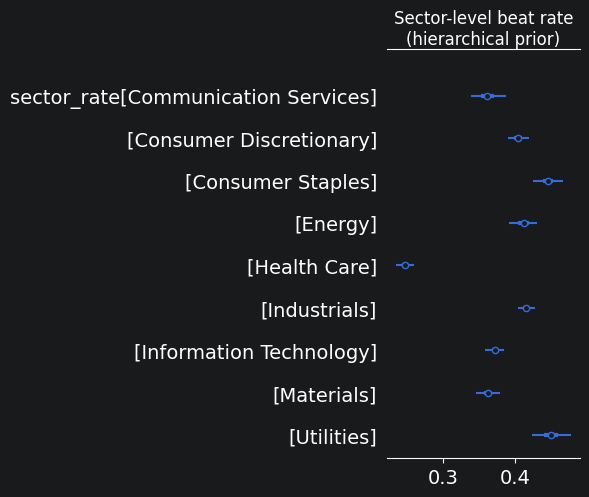

In [9]:
if sectors is not None:
    az.plot_forest(earnings_idata, var_names=["sector_rate"], combined=True)
    plt.title("Sector-level beat rate (hierarchical prior)")
    plt.tight_layout()
    plt.show()


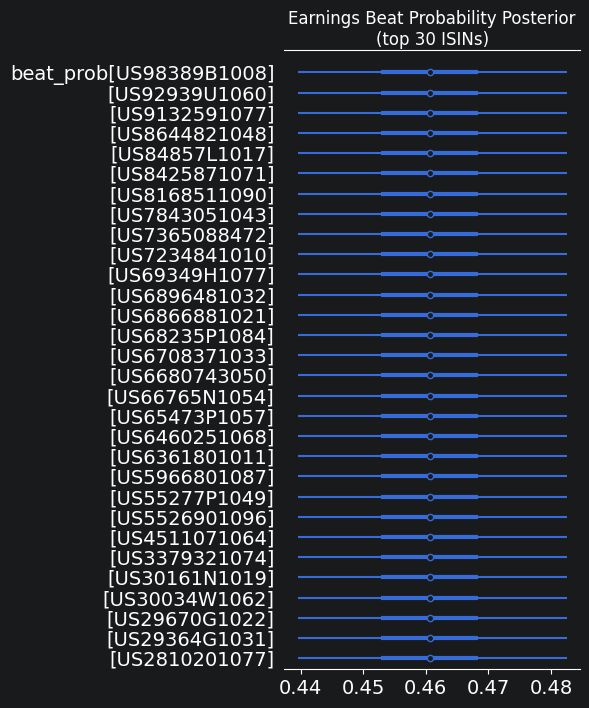

In [12]:
import xarray as xr

post = earnings_idata.posterior
if "beat_prob" in post.data_vars:
    beat_prob = post["beat_prob"]
else:
    kappa = post["kappa"]
    if "sector_rate" in post.data_vars and sectors is not None:
        # Map each ISIN to its sector index (matches the model's sector_idx).
        sector_levels = post.coords["sector"].to_list()
        sector_idx = np.array([sector_levels.index(s) for s in sectors])
        rate_per_isin = post["sector_rate"].isel(
            sector=xr.DataArray(sector_idx, dims="isin")
        )
    else:
        rate_per_isin = 1.0 / (1.0 + np.exp(-post["mu_logit"]))
    alpha_i = rate_per_isin * kappa
    beta_i = (1.0 - rate_per_isin) * kappa
    n_b = xr.DataArray(n_beats, dims="isin")
    n_t = xr.DataArray(n_total, dims="isin")
    beat_prob = (alpha_i + n_b) / (alpha_i + beta_i + n_t)
    beat_prob = beat_prob.assign_coords(isin=isins)
    earnings_idata.posterior = earnings_idata.posterior.assign(beat_prob=beat_prob)

top_n = min(30, len(isins))
beat_mean = beat_prob.mean(("chain", "draw"))
# Use ["isin"] (not .isin) — `.isin` collides with xarray's DataArray.isin() method.
top_isins = beat_mean.sortby(beat_mean, ascending=False)["isin"].values[:top_n]
az.plot_forest(
    earnings_idata,
    var_names=["beat_prob"],
    coords={"isin": top_isins},
    combined=True,
)
plt.title(f"Earnings Beat Probability Posterior (top {top_n} ISINs)")
plt.tight_layout()
plt.show()


## 5. Out-of-sample prediction via `pm.set_data` (illustration)

The `n_total` and `earnings_features` containers are mutable, so new cohorts can be
scored without rebuilding the model graph:

```python
with earnings_bayesian_model:  # the model context returned by fit
    pm.set_data({
        "n_total": new_n_total,
        "earnings_features": new_features_matrix,
    })
    ppc = pm.sample_posterior_predictive(earnings_idata)
```